# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "ResNet50-torch"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Experimental

In [3]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

device = torch.device("cuda:0")
model = models.resnet50().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = model.to(device)


### PyTorch (Baseline)

In [4]:

df = pd.DataFrame()

In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [4.240996346951605, 4.237173645346014, 4.2205658229487435, 4.233378220584478, 4.223387696788655, 4.224993724812259, 4.223756777407886, 4.225711145245277, 4.21703475116341, 4.211727135420382, 4.206189097047926]
4.22408312397424
torch-dynamo-gpu-backward:  [4.717339786726075, 4.508334623129518, 4.510870178204936, 4.515668259816127, 4.517023191527203, 4.514752811676747, 4.510861603325015, 4.508644661253637, 4.509878638494122, 4.504765820194472, 4.515821709893308]
4.530360116749197
       time      pass          item
0  4.224083   Forward  Torch Dynamo
0  4.530360  Backward  Torch Dynamo
0  8.754443      Full  Torch Dynamo


In [6]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
output = model(image)
grad = torch.randn_like(output)


baseline_f = torch_model_benchmark(model, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=21, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=21, 
                                 measure_count=11)
#baseline_b = timeit("torch.autograd.grad(output_native, [image], grad, retain_graph=True)")
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-gpu-forward:  [4.650765231677464, 4.003676984991346, 3.9778008081373715, 3.982064713324819, 3.9629696735313957, 3.959167172156629, 3.9661677022065436, 3.9691209260906493, 3.975578982915197, 3.968813234851474, 3.962729214912369]
4.034441331345024
torch-native-gpu-backward:  [4.423860150078933, 2.9372155577653927, 2.9462151495473727, 2.945593957390104, 2.9519685056237948, 2.9498139130217687, 2.9485519709331647, 2.9430839100054333, 2.9443787144763127, 2.9476607395779517, 2.9519756014148393]
3.080938015439551
       time      pass          item
0  4.224083   Forward  Torch Dynamo
0  4.530360  Backward  Torch Dynamo
0  8.754443      Full  Torch Dynamo
0  4.034441   Forward  Torch Native
0  3.080938  Backward  Torch Native
0  7.115379      Full  Torch Native


In [7]:
df.style.hide(axis="index")

time,pass,item
4.224083,Forward,Torch Dynamo
4.530360,Backward,Torch Dynamo
8.754443,Full,Torch Dynamo
4.034441,Forward,Torch Native
3.080938,Backward,Torch Native
7.115379,Full,Torch Native


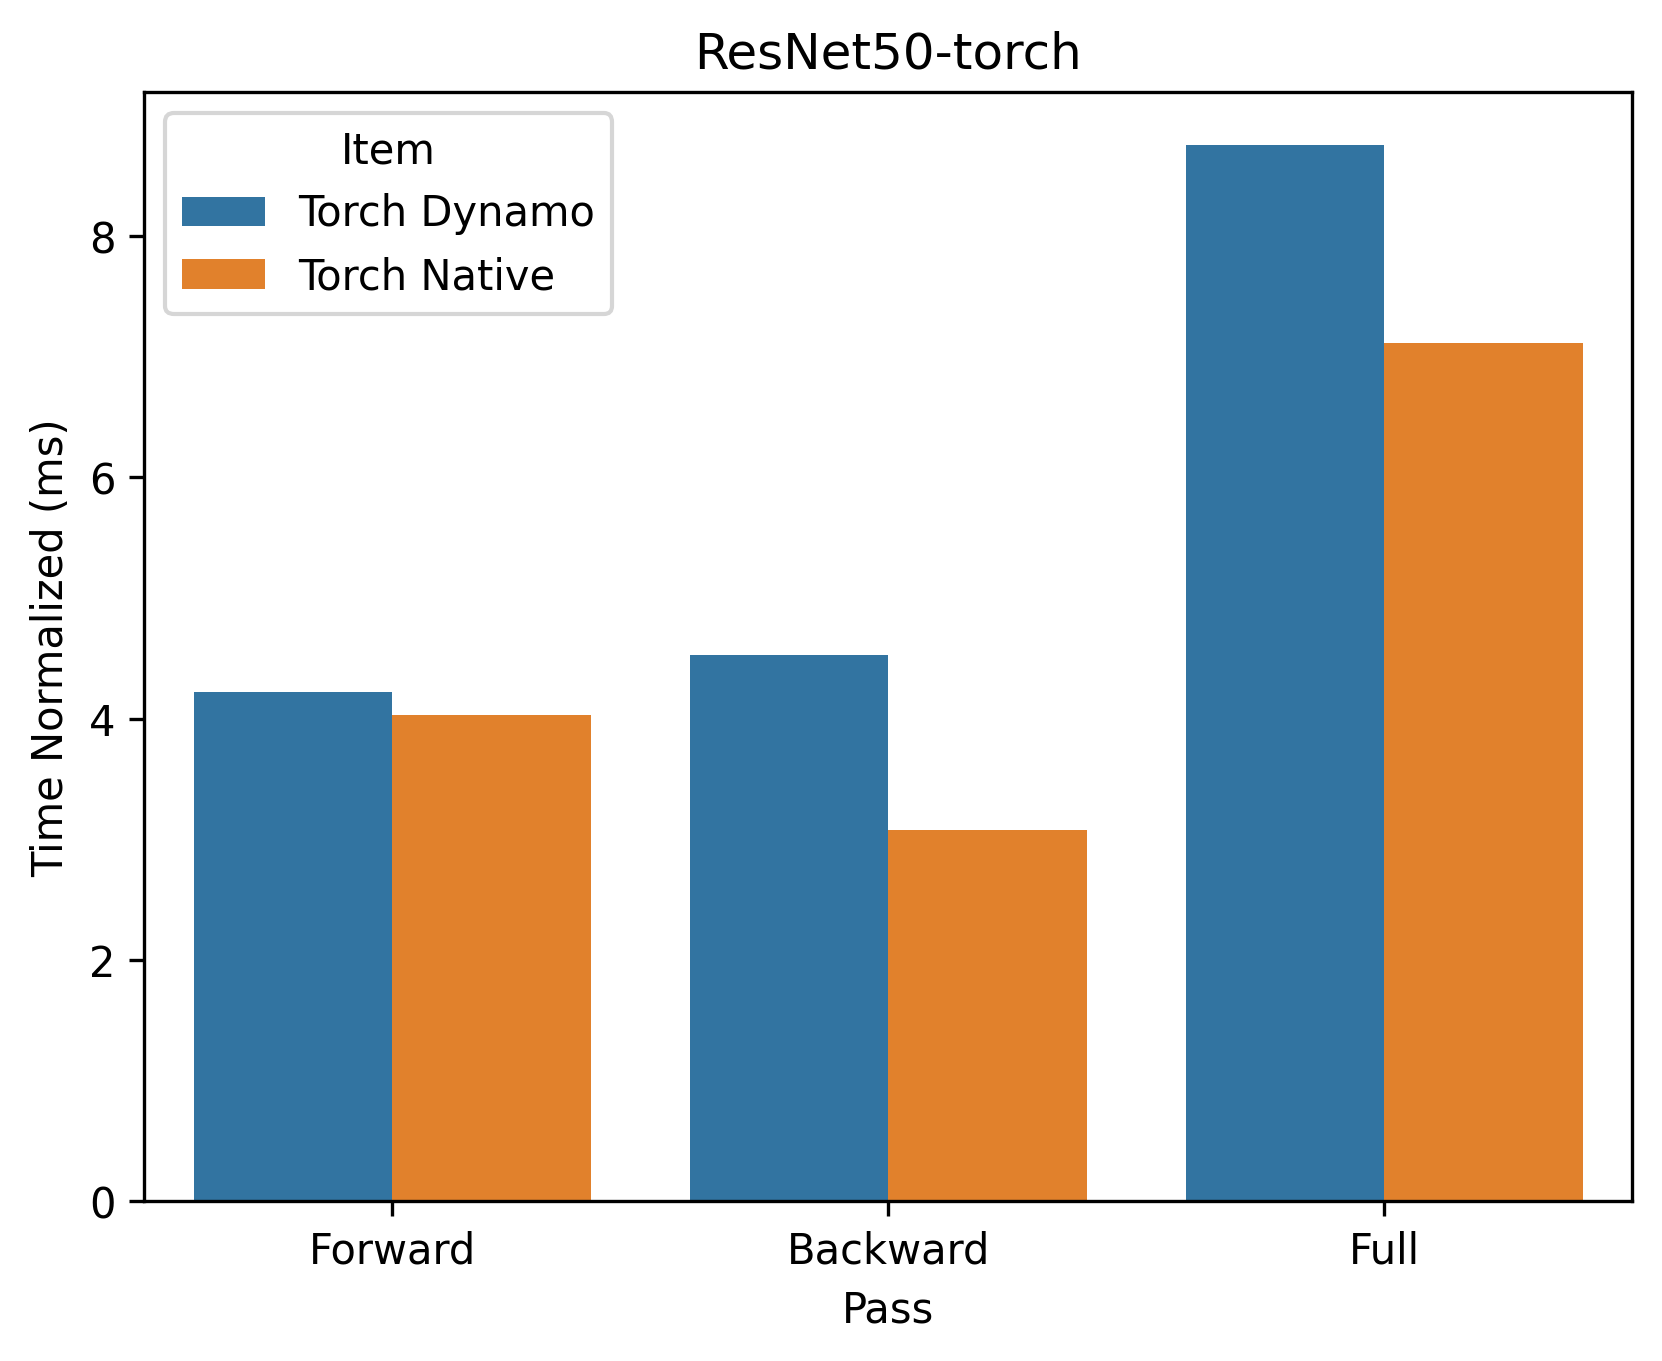

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,4.224083,Forward,Torch Dynamo,0.955105
0,4.034441,Forward,Torch Native,1.000000


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,4.530360,Backward,Torch Dynamo,0.680065
0,3.080938,Backward,Torch Native,1.000000


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,8.754443,Full,Torch Dynamo,0.812773
0,7.115379,Full,Torch Native,1.000000


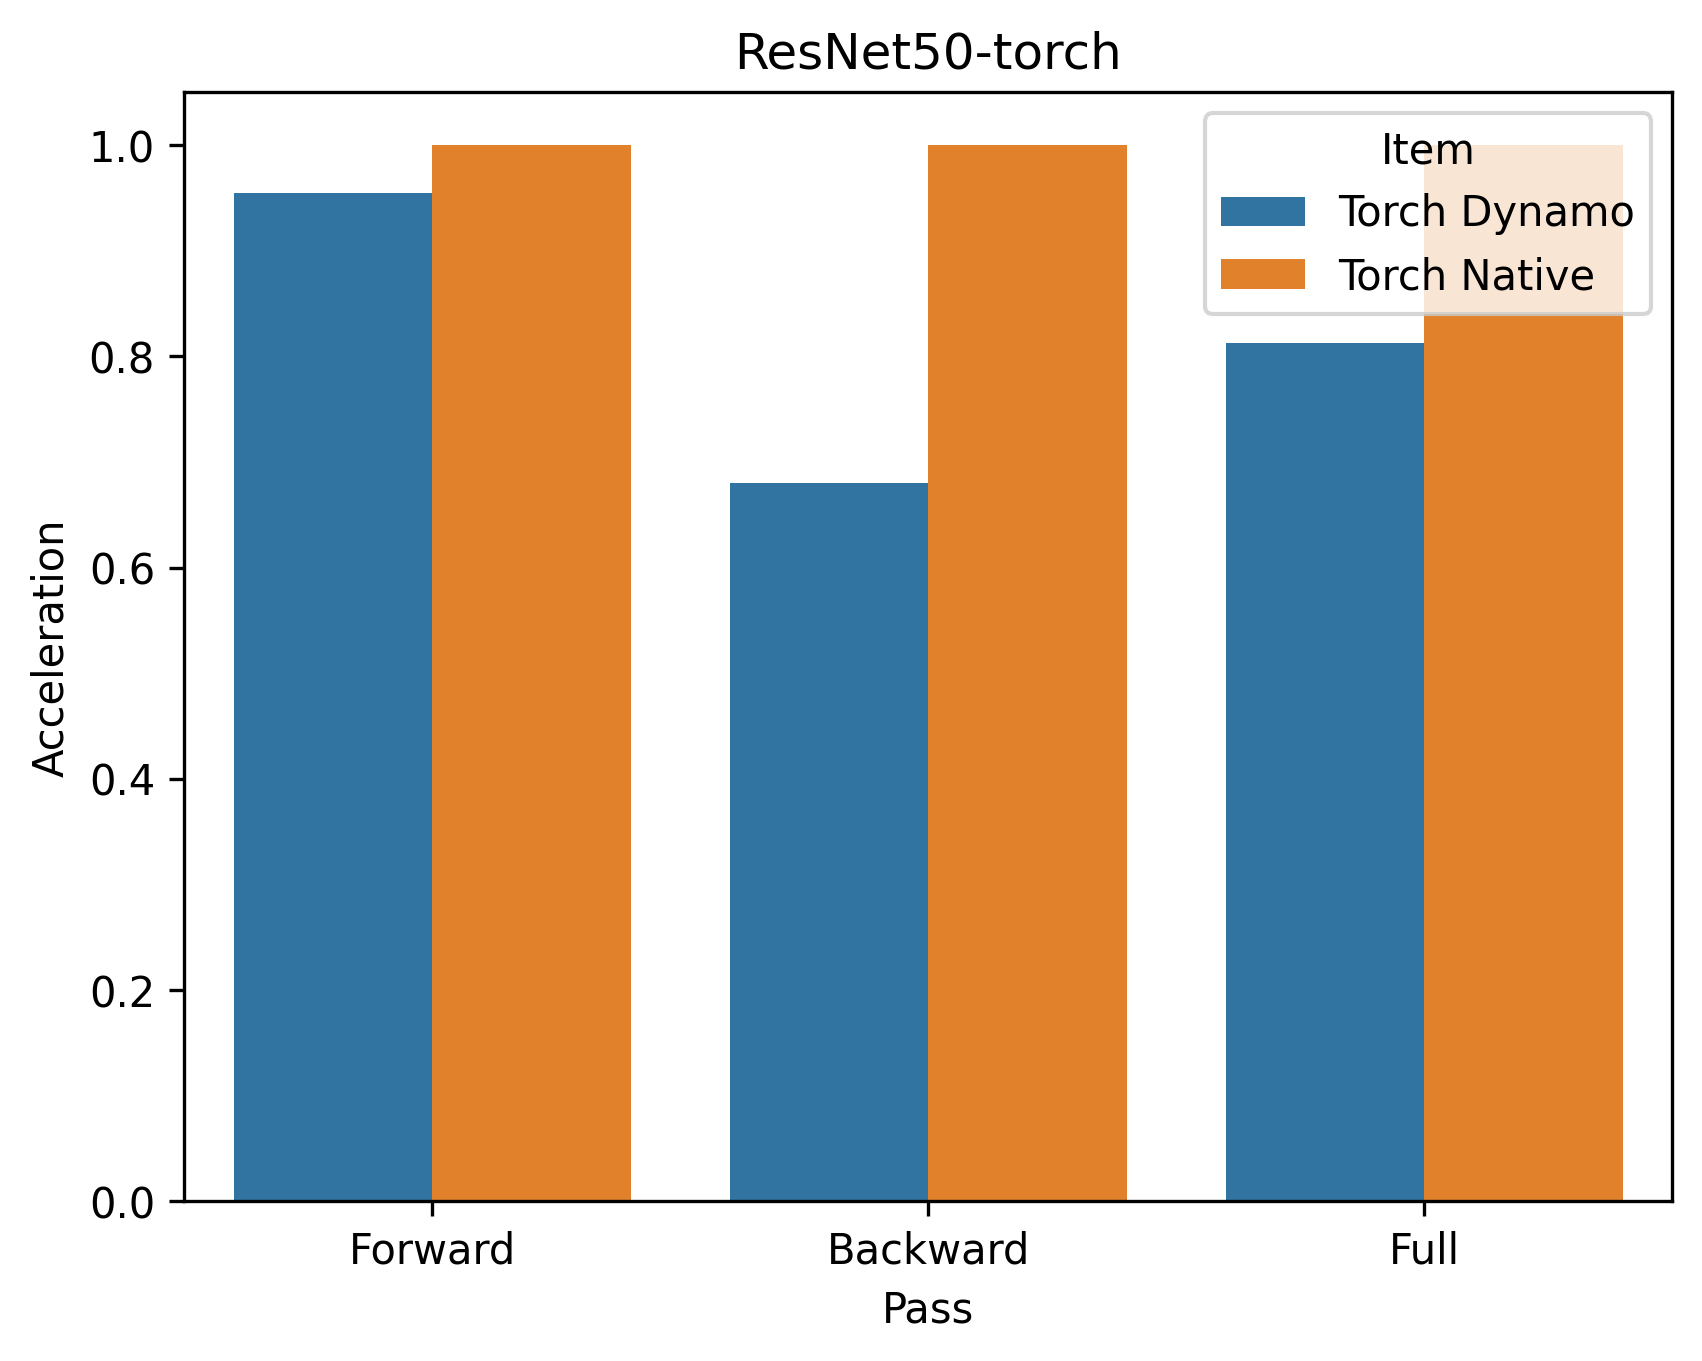

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")